In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares
import scipy
from pathlib import Path

In [2]:
def is_good_cv(x):
    if isinstance(x, str) or x == 0:
        return False

    try:
        v = float(x)
    except (TypeError, ValueError):
        return False

    return np.isfinite(v)

In [3]:
def ma_time(data, time, window_sec):
    ma = []
    ma_time = []
    for i in range(len(data)):
        if time[i] >= window_sec:
            temp_data = []
            for j in range(i+1):
                if time[i] - time[j] <= window_sec:
                    temp_data.append(data[j])
            ma.append(float(np.mean(temp_data)))
            ma_time.append(time[i])
    return ma, ma_time

In [4]:
def clean_mv(cv_raw, time_raw, time_span): 
    if len(cv_raw) != len(time_raw):
        raise ValueError("cv_list and time_list must have the same length")

    keep = [is_good_cv(cv) for cv in cv_raw]

    cv_clean = [cv for cv, k in zip(cv_raw, keep) if k]
    cv_clean = np.array(cv_clean, dtype=float)
    time_clean = [t  for t,  k in zip(time_raw, keep) if k]

    mv_ave, new_time = ma_time(cv_clean, time_clean, time_span)

    return cv_clean, time_clean, mv_ave, new_time

In [5]:
def is_steady(cv_clean, mv_ave, new_time, thr=1.0):
    start = len(new_time)-1
    k = start-1

    steady_time_range = []
    cv_list = []

    for i in range(start):
        dmvdt = abs((mv_ave[k+1] - mv_ave[k-1])/(new_time[k+1] - new_time[k-1]))
        if dmvdt <= thr:
            steady_time_range.append(new_time[k])
            cv_list.append(cv_clean[k])
        else:
            break
        k -= 1

    cv_list = np.array(cv_list)
    mean, std = np.mean(cv_list), np.std(cv_list)
        
    return steady_time_range, mean, std

In [ ]:
data_dir = Path(r"..\..\data\constant_pump_speed_experiment")

# 폴더 안의 모든 pickle 파일
pickle_files = sorted(data_dir.glob("*.pickle"))

TOT_EXP = len(pickle_files)

speed = np.empty(TOT_EXP, dtype=object)
cv = np.empty(TOT_EXP, dtype=object)
time = np.empty(TOT_EXP, dtype=object)

for i, file in enumerate(pickle_files):

    with open(file, "rb") as f:
        data = pickle.load(f)

    pump_speed = data["pump_speed"]
    cv_raw = data["cv"]
    time_raw = data["time"]

    speed[i] = np.array(pump_speed)
    cv[i] = np.array(cv_raw)
    time[i] = np.array(time_raw)

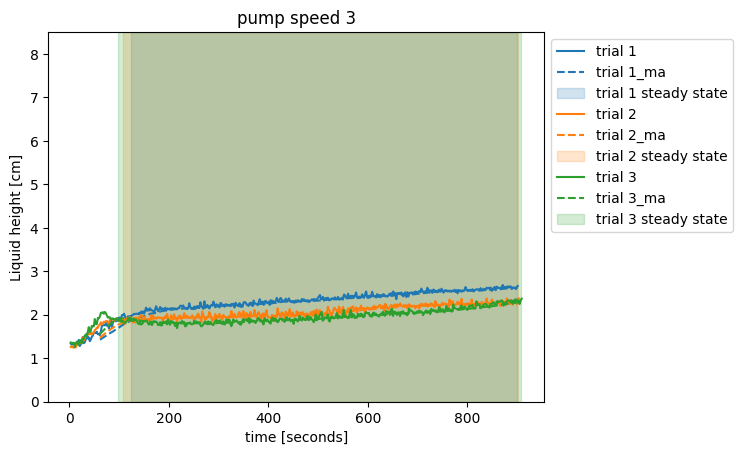

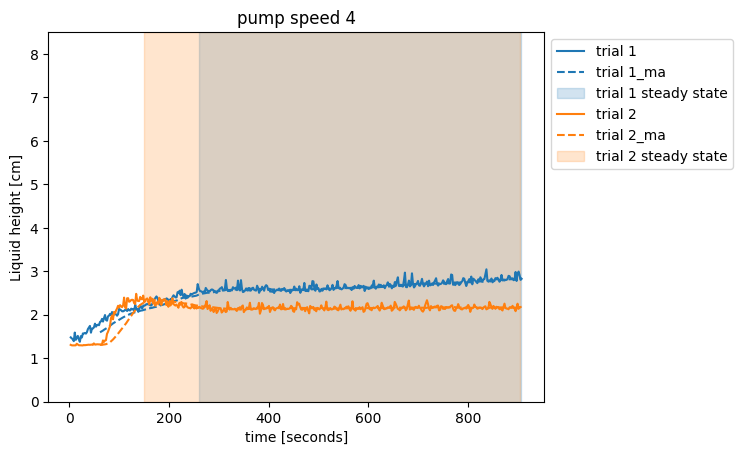

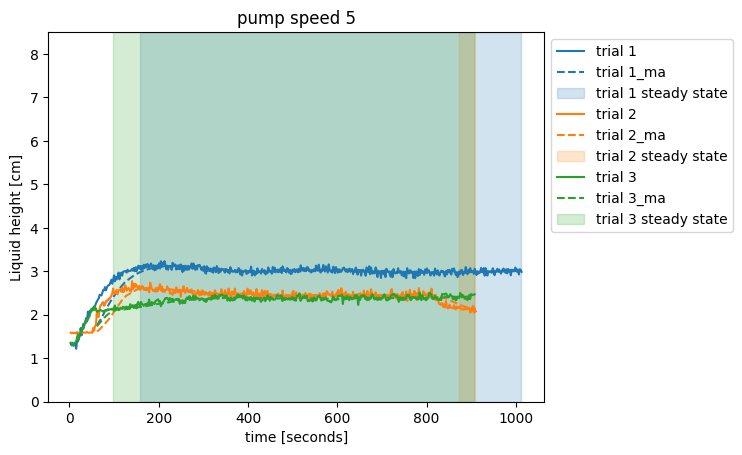

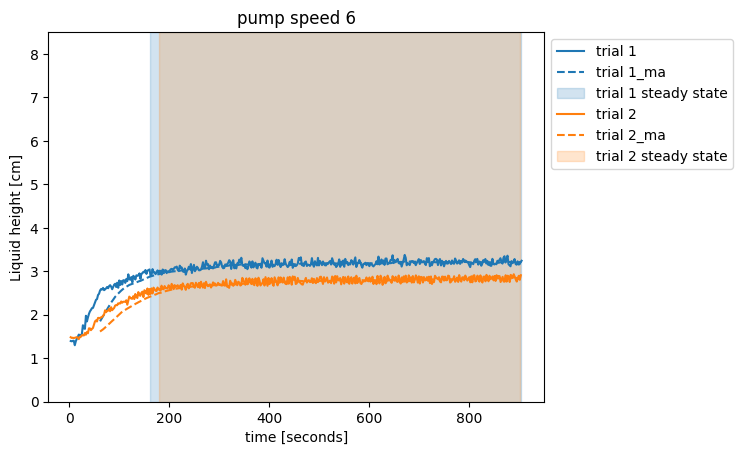

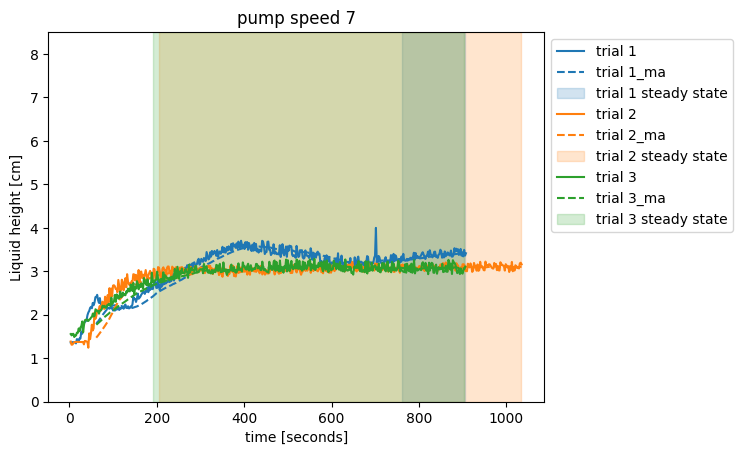

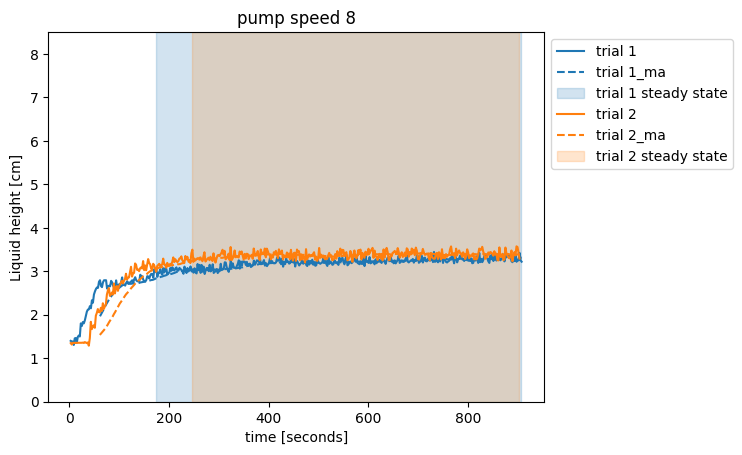

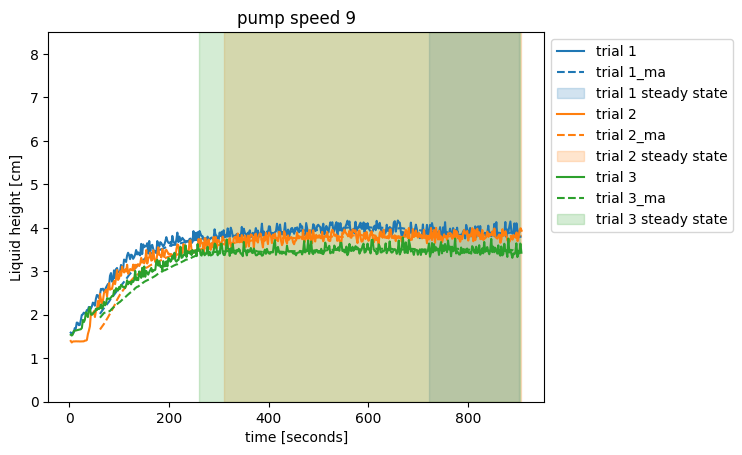

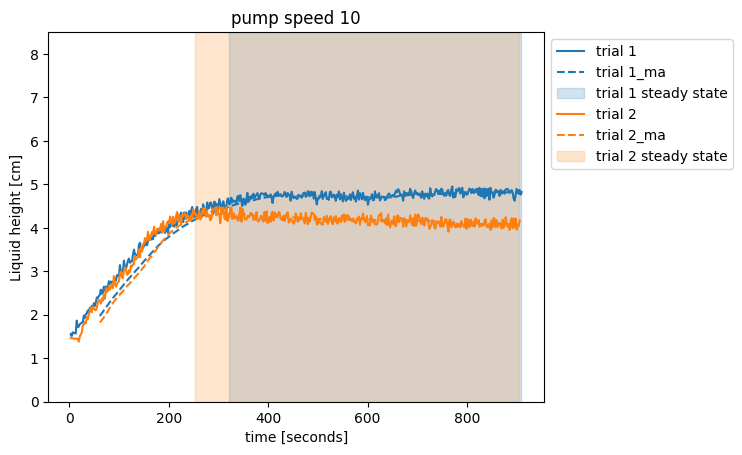

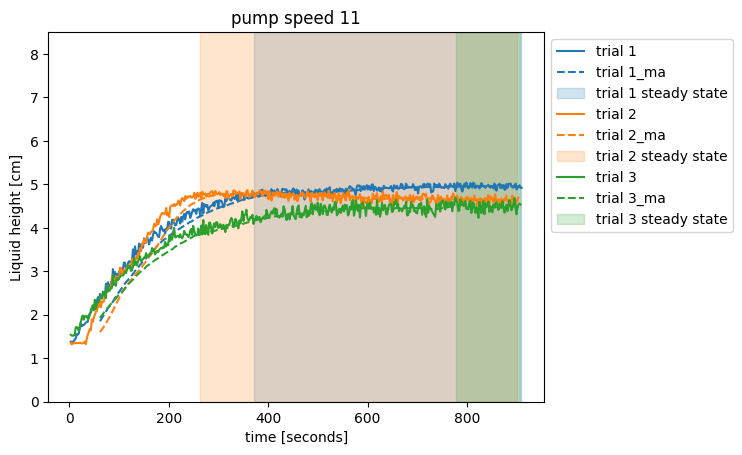

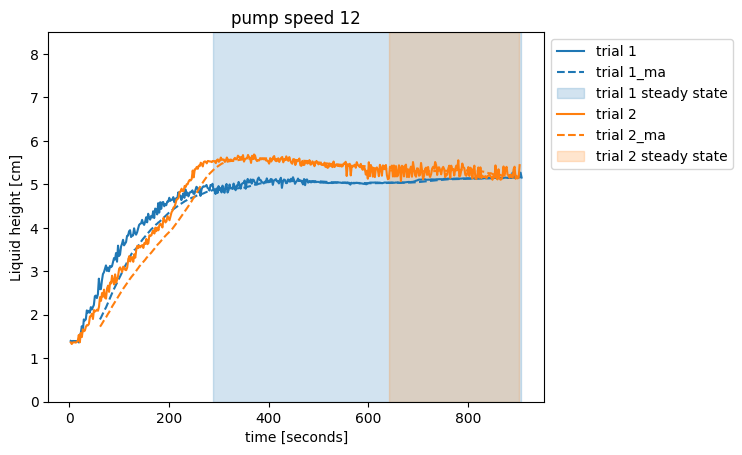

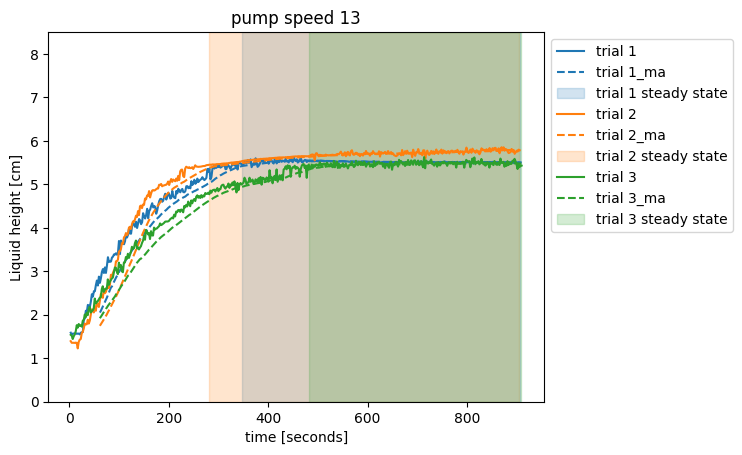

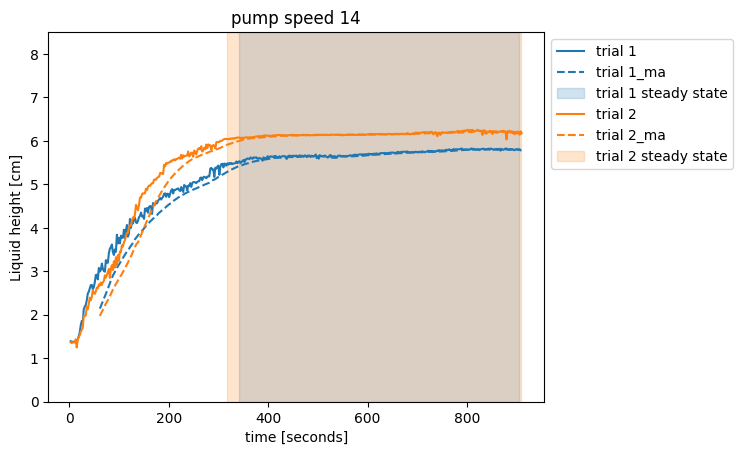

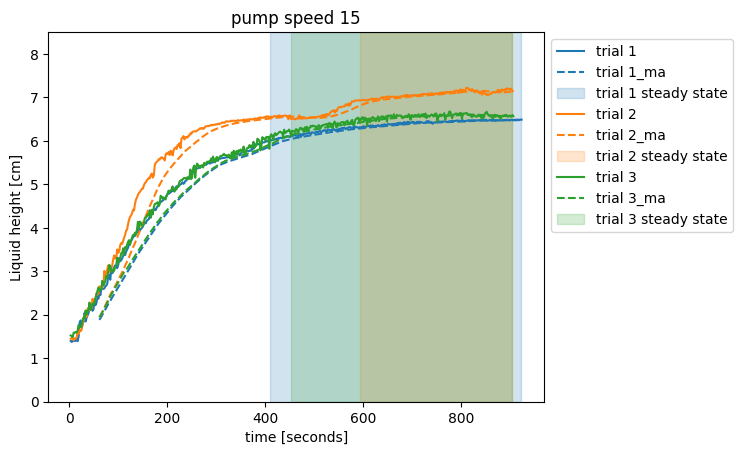

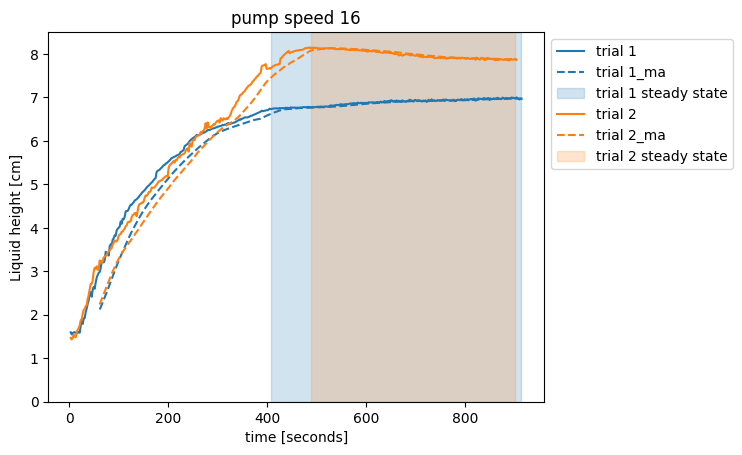

In [7]:
mean = []
std = []
pump_speed = []

time_span = 60
thr=5e-3

for i in range(3, 17):
    indices = [j for j, s in enumerate(speed) if s == i]
    cv_clean, time_clean = np.empty(len(indices), dtype=object), np.empty(len(indices), dtype=object)
    mv, mv_time = np.empty(len(indices), dtype=object), np.empty(len(indices), dtype=object)
    steady_range, steady_mean, steady_std = np.empty(len(indices), dtype=object), np.empty(len(indices), dtype=object), np.empty(len(indices), dtype=object)

    for k in range(len(indices)):
        cv_clean[k], time_clean[k], mv[k], mv_time[k] = clean_mv(cv[indices[k]], time[indices[k]], time_span)
        steady_range[k], steady_mean[k], steady_std[k] = is_steady(cv_clean[k], mv[k], mv_time[k], thr=thr)

        mean.append(steady_mean[k])
        std.append(steady_std[k])
        pump_speed.append(i)

        line, = plt.plot(time_clean[k], cv_clean[k], label=f"trial {k+1}")
        color = line.get_color()
        plt.plot(mv_time[k], mv[k], ls="--", color=color, label=f"trial {k+1}_ma")
        plt.fill_between(steady_range[k], np.zeros(len(steady_range[k])), 8.5*np.ones(len(steady_range[k])), color=color, alpha=0.2, label=f'trial {k+1} steady state')

    plt.legend(bbox_to_anchor = [1,1])
    plt.title(f"pump speed {speed[indices[0]]}")
    plt.xlabel("time [seconds]")
    plt.ylabel("Liquid height [cm]")
    plt.ylim((0, 8.5))
    plt.show()

Text(0.5, 0, 'Pump speed [rpm]')

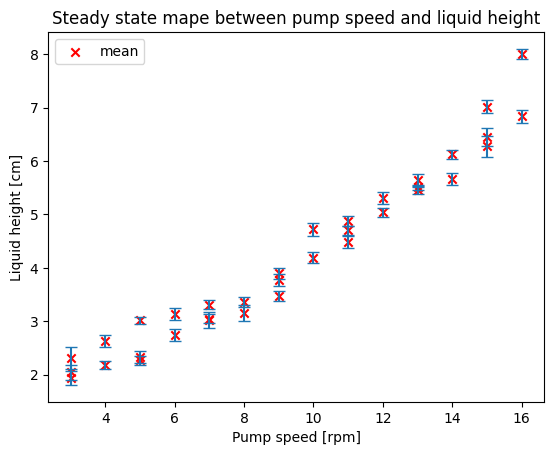

In [8]:
plt.errorbar(pump_speed, mean, yerr=std, fmt="none", capsize=4)
plt.scatter(pump_speed, mean, marker="x", c="r", label="mean")
plt.title("Steady state mape between pump speed and liquid height")
plt.ylabel("Liquid height [cm]")
plt.legend()
plt.xlabel("Pump speed [rpm]")

In [9]:
x = np.array(pump_speed)
x2 = x**2
y = np.array(mean)
std = np.array(std)

def residuals(params, x2, y, std):
    A, B = params
    return (A*x2 + B - y)/std

B0 = 1.5
delta = 10000              # ‘크게’의 기준(예: ±0.1) — 너 상황에 맞게 조정
#lb = [-np.inf, B0 - delta]  # lower bounds: A는 자유, B만 제한
#ub = [ np.inf, B0 + delta]  # upper bounds
#lb = [-np.inf, -np.inf]  # lower bounds: A는 자유, B만 제한
#ub = [ np.inf, np.inf]  # upper bounds

#res = least_squares(residuals, x0=[100.0, B0], bounds=(lb, ub), args=(x2, y))
res = least_squares(residuals, x0=[100.0, B0], args=(x2, y, std))
A_hat, B_hat = res.x
print(A_hat, B_hat)

0.020763515968370103 2.072995944802577


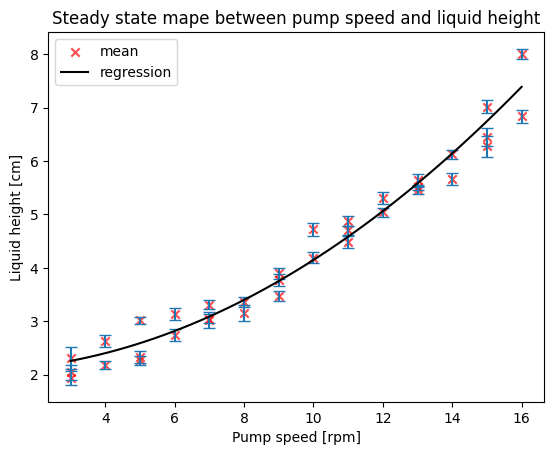

In [10]:
x = np.linspace(3,16,50)
y = A_hat*x**2 + B_hat
plt.errorbar(pump_speed, mean, yerr=std, fmt="none", capsize=4)
plt.scatter(pump_speed, mean, marker="x", c="r", alpha=0.7, label="mean")
plt.plot(x,y, c="k", label="regression")
plt.title("Steady state mape between pump speed and liquid height")
plt.ylabel("Liquid height [cm]")
plt.xlabel("Pump speed [rpm]")
plt.legend()
plt.show()

In [11]:
pump_speed = np.array(pump_speed)
mean = np.array(mean)
std = np.array(std)
exp = A_hat*pump_speed**2 + B_hat
chi2 = np.sum(((mean - exp)/std)**2)
print(f"chi squared value = {chi2} \nTotal number of measurement: {len(mean)}, actual number of parameters: {res.x.shape[0]}")
dof = len(mean) - res.x.shape[0]
alpha = 0.1
print(f"Therefore degree of freedom: {dof}, alpha = {alpha}")
critical_chi2 = scipy.stats.chi2.isf(alpha, dof)
print(f"Critical chi-squared value: {critical_chi2}")
passed = chi2 <= critical_chi2
print("Goodness of fit test passed?", passed)

chi squared value = 252.07406157009405 
Total number of measurement: 35, actual number of parameters: 2
Therefore degree of freedom: 33, alpha = 0.1
Critical chi-squared value: 43.74517955943419
Goodness of fit test passed? False


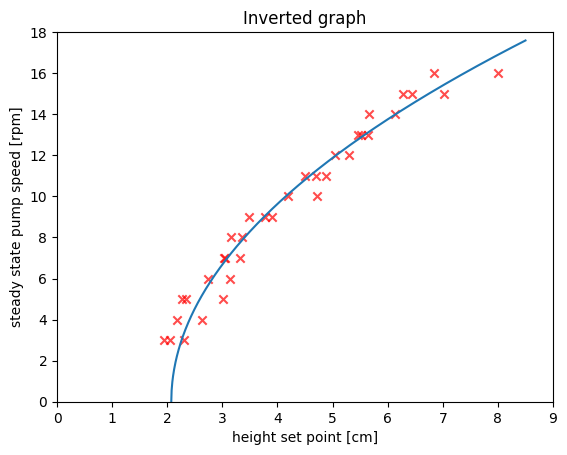

the steady state pump speed should be between (0, 17.593564554567234)


In [12]:
plt.scatter(mean, pump_speed, marker="x", c="r", alpha=0.7, label="mean")
x = np.linspace(B_hat, 8.5, 1000)
y = np.sqrt((x - B_hat)/A_hat)
plt.plot(x,y)
plt.xlabel("height set point [cm]")
plt.ylabel("steady state pump speed [rpm]")
plt.xlim((0, 9))
plt.ylim((0, 18))
plt.title("Inverted graph")
plt.show()
print(f"the steady state pump speed should be between ({0}, {y.max()})")

In [ ]:
param = {
    "B": B_hat,
    "A": A_hat
}
with open(r"..\..\parameters\steady_state_param.pickle", "wb") as f:
    pickle.dump(param, f)